In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
puneet6060_intel_image_classification_path = kagglehub.dataset_download('puneet6060/intel-image-classification')

print('Data source import complete.')


Using Colab cache for faster access to the 'intel-image-classification' dataset.
Data source import complete.


# **Imports**

In [2]:
import os
import glob
import shutil
import random
import hashlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Mixed precision: بيشغّل حسابات الـ GPU بـ float16 بدل float32
# ده بيسرّع التدريب ضعفين ويسمح بـ batch size أكبر
tf.keras.mixed_precision.set_global_policy('mixed_float16')

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('Mixed precision policy:', tf.keras.mixed_precision.global_policy())


TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


# **Upload DataSet (Intel Image Classification)**

In [3]:
import kagglehub

path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Downloaded to:", path)

# نلاقي الـ seg_train الصح
candidates = glob.glob(os.path.join(path, '**', 'seg_train', 'seg_train'), recursive=True)
if not candidates:
    candidates = glob.glob(os.path.join(path, '**', 'seg_train'), recursive=True)

RAW_PATH = candidates[0]
print("Raw path:", RAW_PATH)
print("Classes:", sorted(os.listdir(RAW_PATH)))


Using Colab cache for faster access to the 'intel-image-classification' dataset.
Downloaded to: /kaggle/input/intel-image-classification
Raw path: /kaggle/input/intel-image-classification/seg_train/seg_train
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [4]:
# نجمع كل الصور في folder نظيف واحد
CLEAN_DIR = Path("/content/Intel_clean")
CLEAN_DIR.mkdir(exist_ok=True)

for cls in os.listdir(RAW_PATH):
    src = Path(RAW_PATH) / cls
    dst = CLEAN_DIR / cls
    if src.is_dir():
        shutil.copytree(src, dst, dirs_exist_ok=True)

print("Classes copied:", sorted(os.listdir(CLEAN_DIR)))


Classes copied: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# **EDA**

In [5]:
DATA_DIR = Path("/content/Intel_clean")
CLASSES  = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASSES)

print("Classes :", CLASSES)
print("Num classes:", NUM_CLASSES)


Classes : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Num classes: 6


In [6]:
# عد الصور لكل class
class_counts = {}
for cls in CLASSES:
    imgs = list((DATA_DIR / cls).glob("*.[jp][pn]g")) + \
           list((DATA_DIR / cls).glob("*.jpeg"))
    class_counts[cls] = len(imgs)

for cls, cnt in class_counts.items():
    print(f"{cls:15s}: {cnt}")


buildings      : 2191
forest         : 2271
glacier        : 2404
mountain       : 2512
sea            : 2274
street         : 2382


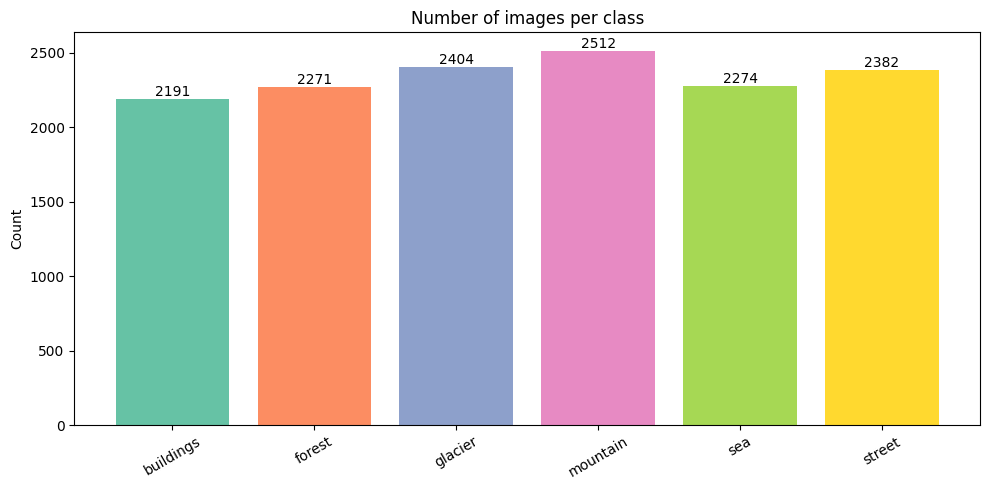

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_counts.keys(), class_counts.values(),
              color=plt.cm.Set2.colors[:NUM_CLASSES])
ax.bar_label(bars)
ax.set_title("Number of images per class")
ax.set_ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


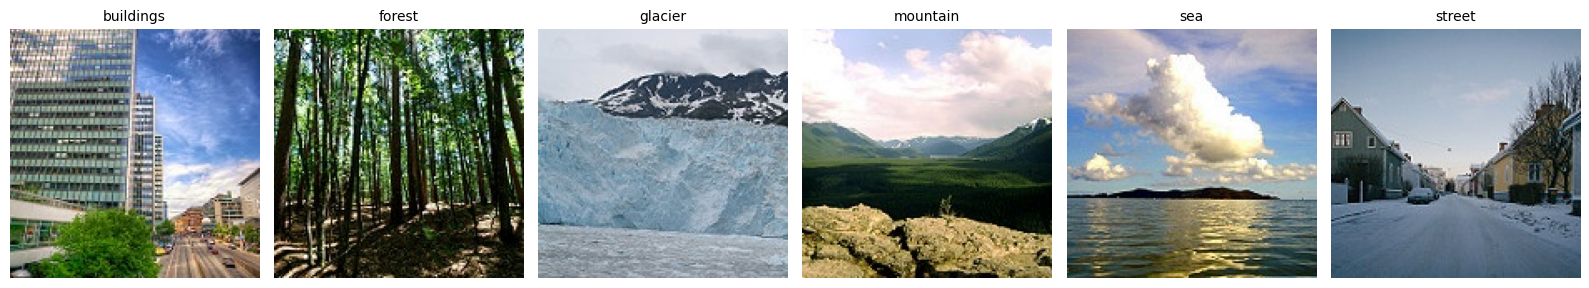

In [8]:
# عرض صورة من كل class
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 3))
for ax, cls in zip(axes, CLASSES):
    img_path = next((DATA_DIR / cls).glob("*.[jp][pn]g"))
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [9]:
# شكل الصور
sample_path = next((DATA_DIR / CLASSES[0]).glob("*.[jp][pn]g"))
sample_arr  = np.array(Image.open(sample_path))
print("Image shape:", sample_arr.shape)


Image shape: (150, 150, 3)


In [10]:
# Pixel statistics
all_means, all_stds = [], []
for cls in CLASSES:
    for p in list((DATA_DIR / cls).glob("*.[jp][pn]g"))[:30]:
        arr = np.array(Image.open(p).convert("RGB"), dtype=np.float32)
        all_means.append(arr.mean())
        all_stds.append(arr.std())

print(f"Mean pixel value : {np.mean(all_means):.2f}")
print(f"Std  pixel value : {np.mean(all_stds):.2f}")


Mean pixel value : 114.20
Std  pixel value : 61.85


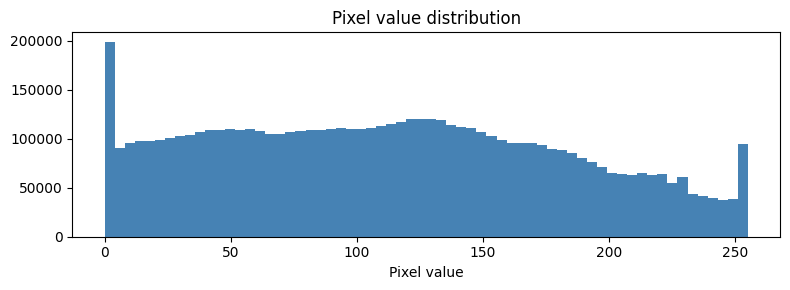

In [11]:
# Pixel distribution
pixels = []
for cls in CLASSES:
    for p in list((DATA_DIR / cls).glob("*.[jp][pn]g"))[:15]:
        pixels.extend(np.array(Image.open(p).convert("RGB")).ravel().tolist())

plt.figure(figsize=(8, 3))
plt.hist(pixels, bins=64, color="steelblue", edgecolor="none")
plt.title("Pixel value distribution")
plt.xlabel("Pixel value")
plt.tight_layout()
plt.show()


In [12]:
# فحص الصور التالفة
corrupted = []
for cls in CLASSES:
    for p in (DATA_DIR / cls).iterdir():
        if not p.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            continue
        try:
            with Image.open(p) as img:
                img.verify()
        except Exception:
            corrupted.append(str(p))

print(f"Corrupted images: {len(corrupted)}")


Corrupted images: 0


In [13]:
# فحص الـ folders الفاضية
empty = [cls for cls in CLASSES
         if len(list((DATA_DIR / cls).glob("*.[jp][pn]g"))) == 0]
print("Empty classes:", empty if empty else "None ")


Empty classes: None 


In [14]:
# فحص الصور المكررة
seen_hashes = set()
duplicates  = 0
for cls in CLASSES:
    for p in list((DATA_DIR / cls).glob("*.[jp][pn]g"))[:100]:
        h = hashlib.md5(p.read_bytes()).hexdigest()
        if h in seen_hashes:
            duplicates += 1
        else:
            seen_hashes.add(h)
print(f"Duplicate images (sample): {duplicates}")


Duplicate images (sample): 0


In [15]:
# فحص أحجام الصور المختلفة
sizes = set()
for cls in CLASSES:
    for p in list((DATA_DIR / cls).glob("*.[jp][pn]g"))[:30]:
        with Image.open(p) as img:
            sizes.add(img.size)
print("Unique sizes found:", sizes)


Unique sizes found: {(150, 150)}


# **Data Splitting**
> **نسبة جديدة 80/10/10** — نديّ الموديل داتا أكتر للـ training عشان يتعلم أحسن


In [16]:
SPLIT_DIR  = Path("/content/Intel_split")
TRAIN_DIR  = SPLIT_DIR / "train"
VAL_DIR    = SPLIT_DIR / "val"
TEST_DIR   = SPLIT_DIR / "test"


In [17]:
for split in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    split.mkdir(parents=True, exist_ok=True)


In [18]:
# نسبة 80/10/10: train أكبر = موديل أقوى
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
# TEST_RATIO  = 0.10

for cls in CLASSES:
    all_imgs = sorted((DATA_DIR / cls).glob('*.[jp][pn]g'))
    random.shuffle(all_imgs)

    n       = len(all_imgs)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    splits = {
        TRAIN_DIR: all_imgs[:n_train],
        VAL_DIR  : all_imgs[n_train : n_train + n_val],
        TEST_DIR : all_imgs[n_train + n_val :]
    }

    for dest_dir, imgs in splits.items():
        (dest_dir / cls).mkdir(exist_ok=True)
        for img_path in imgs:
            shutil.copy(img_path, dest_dir / cls / img_path.name)

print('Splitting done!')
for split, d in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    total = sum(len(list((d/c).glob('*'))) for c in CLASSES)
    print(f'  {split}: {total} images')


Splitting done!
  Train: 11224 images
  Val: 1402 images
  Test: 1408 images


# **Preprocessing CNN**


In [19]:
IMG_H, IMG_W = 160, 160
BATCH_SIZE   = 64   # أكبر بفضل mixed precision
AUTOTUNE     = tf.data.AUTOTUNE

def load_and_preprocess_cnn(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_H, IMG_W])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment_cnn(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.3)
    img = tf.image.random_contrast(img, 0.7, 1.3)
    img = tf.image.random_saturation(img, 0.7, 1.3)
    img = tf.image.random_hue(img, max_delta=0.1)
    k   = tf.random.uniform([], 0, 4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    # Random crop + resize (بيحاكي zoom in/out)
    img = tf.image.random_crop(img, size=[128, 128, 3])
    img = tf.image.resize(img, [IMG_H, IMG_W])
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


In [20]:
def build_dataset(split_dir, augment=False, shuffle=True):
    paths, labels = [], []
    for idx, cls in enumerate(CLASSES):
        for p in (split_dir / cls).glob('*.[jp][pn]g'):
            paths.append(str(p))
            labels.append(idx)

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, tf.one_hot(labels, NUM_CLASSES))
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_and_preprocess_cnn, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_cnn, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds, len(paths)

train_ds, n_train = build_dataset(TRAIN_DIR, augment=True,  shuffle=True)
val_ds,   n_val   = build_dataset(VAL_DIR,   augment=False, shuffle=False)
test_ds,  n_test  = build_dataset(TEST_DIR,  augment=False, shuffle=False)

print(f'Train: {n_train} | Val: {n_val} | Test: {n_test}')


Train: 11224 | Val: 1402 | Test: 1408


In [21]:
# نتأكد إن الـ dataset اتبنى صح
for imgs, labels in train_ds.take(1):
    print("Image batch shape:", imgs.shape)
    print("Label batch shape:", labels.shape)


Image batch shape: (64, 160, 160, 3)
Label batch shape: (64, 6)


# **Model 1 (Simple CNN)**

In [22]:
def se_block(x, ratio=16):
    """Squeeze-and-Excitation Block: بيعيد وزن كل channel حسب أهميته"""
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // ratio, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.Multiply()([x, se])

def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 3, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = se_block(x)  # SE block بعد كل residual
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    return layers.Activation('relu')(x)

def build_cnn(num_classes, input_shape=(160, 160, 3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(64, 3, strides=2, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    for filters, drop in [(64, 0.2), (128, 0.25), (256, 0.3), (512, 0.35)]:
        x = residual_block(x, filters)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Dropout(drop)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.45)(x)
    # Output بـ float32 دايماً حتى مع mixed precision
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    return keras.Model(inputs, outputs, name='SE_ResNet_CNN')

cnn_model = build_cnn(NUM_CLASSES)
cnn_model.summary()


Model: "SE_ResNet_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 80, 80,    │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 80, 80,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 80, 80,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 80, 80,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        320 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 80, 80,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 80, 80,    │          0 │ multiply[0][0],   │
│                     │ 64)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 80, 80,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 40, 40,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 40, 40,    │          0 │ max_pooling2d[0]

 Total params: 5,219,074 (19.91 MB)

 Trainable params: 5,212,290 (19.88 MB)

 Non-trainable params: 6,784 (26.50 KB)

In [23]:
steps_per_epoch = n_train // BATCH_SIZE

# Cosine Decay with Restarts: بيعمل warm restarts عشان يتجنب local minima
cosine_restarts = CosineDecayRestarts(
    initial_learning_rate=1e-3,
    first_decay_steps=steps_per_epoch * 10,
    t_mul=2.0,
    m_mul=0.9,
    alpha=1e-6
)

# AdamW: Adam + Weight Decay مدمج بشكل صح (أفضل من Adam + L2)
cnn_model.compile(
    optimizer=AdamW(learning_rate=cosine_restarts, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [24]:
cnn_model.summary()


Model: "SE_ResNet_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 80, 80,    │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 80, 80,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 80, 80,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 80, 80,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        320 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 80, 80,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 80, 80,    │          0 │ multiply[0][0],   │
│                     │ 64)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 80, 80,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 40, 40,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 40, 40,    │          0 │ max_pooling2d[0]

 Total params: 5,219,074 (19.91 MB)

 Trainable params: 5,212,290 (19.88 MB)

 Non-trainable params: 6,784 (26.50 KB)

In [25]:
all_labels = []
for idx, cls in enumerate(CLASSES):
    n = len(list((TRAIN_DIR / cls).glob('*.[jp][pn]g')))
    all_labels.extend([idx] * n)

cw = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
class_weights = dict(enumerate(cw))
print('Class weights:', class_weights)

cnn_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        '/content/best_cnn.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

Class weights: {0: np.float64(1.0677321156773212), 1: np.float64(1.0301027900146842), 2: np.float64(0.9727855780897903), 3: np.float64(0.9311431889829103), 4: np.float64(1.0284038849184534), 5: np.float64(0.9819772528433945)}


In [26]:
from tensorflow.keras.optimizers import AdamW

optimizer = AdamW(
    learning_rate=cosine_restarts,
    weight_decay=1e-4
)

In [27]:
cnn_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=cnn_callbacks,
    class_weight=class_weights
)

Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.3669 - loss: 1.8747
Epoch 1: val_accuracy improved from None to 0.17832, saving model to /content/best_cnn.keras

Epoch 1: finished saving model to /content/best_cnn.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 144s 396ms/step - accuracy: 0.4184 - loss: 1.6978 - val_accuracy: 0.1783 - val_loss: 2.6756
Epoch 2/50
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.5138 - loss: 1.4427
Epoch 2: val_accuracy improved from 0.17832 to 0.37090, saving model to /content/best_cnn.keras

Epoch 2: finished saving model to /content/best_cnn.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 23s 128ms/step - accuracy: 0.5404 - loss: 1.3898 - val_accuracy: 0.3709 - val_loss: 2.0701
Epoch 3/50
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5886 - loss: 1.2762
Epoch 3: val_accuracy improved from 0.37090 to 0.42582, saving model to /content/best_cnn.keras

Epoch 3: finished saving model to /content/best_cnn.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 23s 

In [29]:
print("Train Accuracy    :", max(cnn_history.history['accuracy']))
print("Validation Accuracy:", max(cnn_history.history['val_accuracy']))


Train Accuracy    : 0.85566645860672
Validation Accuracy: 0.863766074180603


In [30]:
cnn_loss, cnn_acc = cnn_model.evaluate(test_ds)
print(f"Test Accuracy: {cnn_acc:.4f}")


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8658 - loss: 0.5083
Test Accuracy: 0.8658


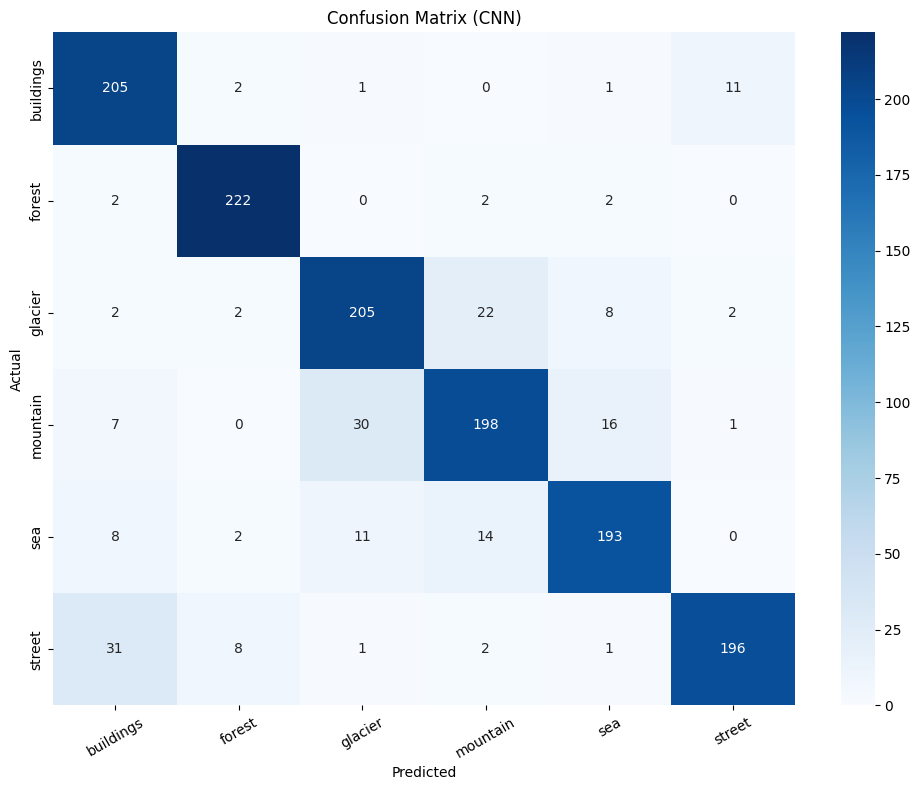

In [31]:
# Confusion Matrix للـ CNN
y_true_cnn, y_pred_cnn = [], []
for imgs, labels in test_ds:
    preds = cnn_model.predict(imgs, verbose=0)
    y_pred_cnn.extend(np.argmax(preds, axis=1))
    y_true_cnn.extend(np.argmax(labels.numpy(), axis=1))

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (CNN)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


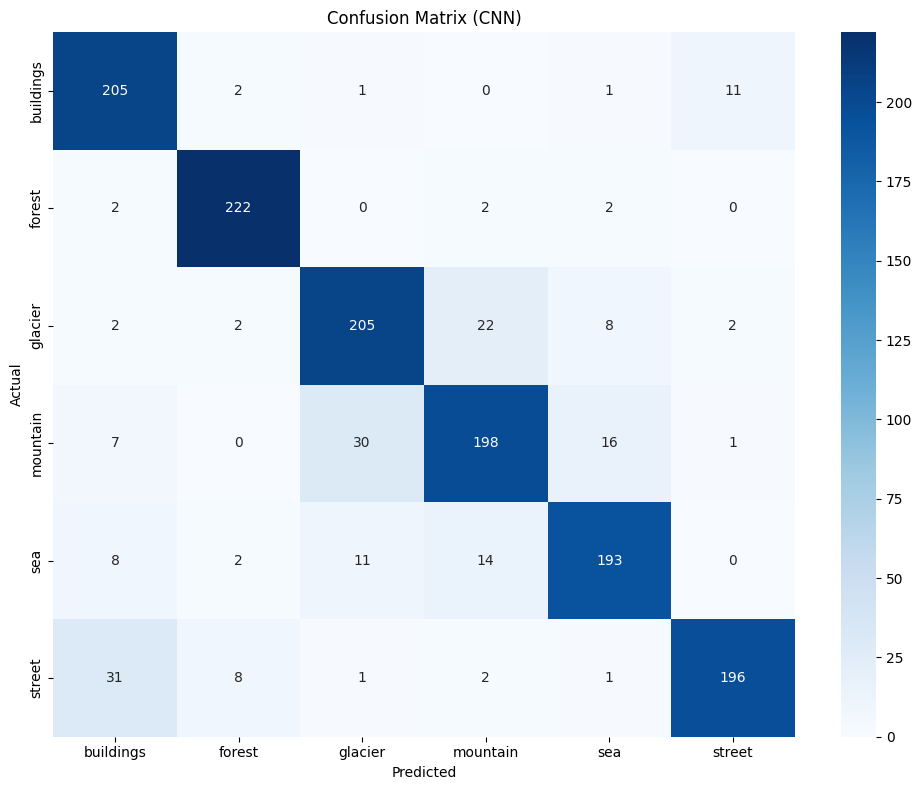

In [32]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (CNN)")
plt.tight_layout()
plt.show()


# **Preprocessing EfficientNetV2S**


In [33]:
# EfficientNetV2S: أحدث وأقوى من MobileNetV2
# بيستخدم image size 384x384 لكن 300 كافية وأسرع
EFF_IMG = 300

def load_and_preprocess_eff(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [EFF_IMG, EFF_IMG])
    # EfficientNetV2 بيعمل الـ normalization internally — بنبعت القيم كـ [0,255]
    img = tf.cast(img, tf.float32)
    return img, label

def augment_eff(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=40)
    img = tf.image.random_contrast(img, 0.7, 1.3)
    img = tf.image.random_saturation(img, 0.7, 1.3)
    img = tf.image.random_hue(img, max_delta=0.1)
    k   = tf.random.uniform([], 0, 4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    # Random crop + resize
    img = tf.image.random_crop(img, size=[250, 250, 3])
    img = tf.image.resize(img, [EFF_IMG, EFF_IMG])
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img, label


In [34]:
def build_eff_dataset(split_dir, augment=False, shuffle=True):
    paths, labels = [], []
    for idx, cls in enumerate(CLASSES):
        for p in (split_dir / cls).glob('*.[jp][pn]g'):
            paths.append(str(p))
            labels.append(idx)

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, tf.one_hot(labels, NUM_CLASSES))
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_and_preprocess_eff, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_eff, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(32).prefetch(AUTOTUNE)
    return ds

train_eff_ds = build_eff_dataset(TRAIN_DIR, augment=True,  shuffle=True)
val_eff_ds   = build_eff_dataset(VAL_DIR,   augment=False, shuffle=False)
test_eff_ds  = build_eff_dataset(TEST_DIR,  augment=False, shuffle=False)

print('EfficientNetV2S datasets ready!')


EfficientNetV2S datasets ready!


# **Model 2 (EfficientNetV2S)**


In [35]:
# EfficientNetV2S: أحدث نسخة من EfficientNet
# include_preprocessing=True: بيعمل normalization داخلياً
base_eff = EfficientNetV2S(
    input_shape=(EFF_IMG, EFF_IMG, 3),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True  # normalization مدمجة
)
base_eff.trainable = False

inputs = keras.Input(shape=(EFF_IMG, EFF_IMG, 3))
x = base_eff(inputs, training=False)

# Dual Pooling: بنجمع GlobalAvgPool و GlobalMaxPool مع بعض
# ده بيدي الموديل معلومات أكتر عن كل feature map
avg = layers.GlobalAveragePooling2D()(x)
mx  = layers.GlobalMaxPooling2D()(x)
x   = layers.Concatenate()([avg, mx])

x = layers.Dense(1024, kernel_regularizer=regularizers.l2(1e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)
# dtype float32 مهم مع mixed precision
outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

eff_model = keras.Model(inputs, outputs, name='EfficientNetV2S_Transfer')
print('Trainable params (Phase 1):',
      sum(np.prod(v.shape) for v in eff_model.trainable_variables))


82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Trainable params (Phase 1): 3153414


In [36]:
eff_model.compile(
    optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)


In [37]:
callbacks_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/eff_phase1.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('=== Phase 1: Training Head Only ===')
history_eff = eff_model.fit(
    train_eff_ds,
    validation_data=val_eff_ds,
    epochs=20,
    callbacks=callbacks_p1,
    class_weight=class_weights
)


=== Phase 1: Training Head Only ===
Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.7062 - loss: 1.0982
Epoch 1: val_accuracy improved from None to 0.86020, saving model to /content/eff_phase1.keras

Epoch 1: finished saving model to /content/eff_phase1.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 295s 573ms/step - accuracy: 0.7636 - loss: 0.9752 - val_accuracy: 0.8602 - val_loss: 0.7656 - learning_rate: 0.0010
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.8072 - loss: 0.8584
Epoch 2: val_accuracy improved from 0.86020 to 0.86662, saving model to /content/eff_phase1.keras

Epoch 2: finished saving model to /content/eff_phase1.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 62s 177ms/step - accuracy: 0.8109 - loss: 0.8499 - val_accuracy: 0.8666 - val_loss: 0.7185 - learning_rate: 0.0010
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8267 - loss: 0.8154
Epoch 3: val_accuracy improved from 0.86662 to 0.88231, saving model to /content/eff_phase1.kera

In [38]:
print('Train Accuracy (P1)     :', max(history_eff.history['accuracy']))
print('Validation Accuracy (P1):', max(history_eff.history['val_accuracy']))


Train Accuracy (P1)     : 0.8915716409683228
Validation Accuracy (P1): 0.9151212573051453


In [39]:
# Phase 2: نفتح كل الـ base ونشيّل الـ BatchNorm من الـ fine-tuning
base_eff.trainable = True

# نجمّد الـ BatchNorm layers عشان الـ statistics متتغيرش
for layer in base_eff.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print('Trainable layers (Phase 2):',
      sum(1 for l in base_eff.layers if l.trainable))

# Cosine Restarts للـ fine-tuning بـ LR أصغر
steps_ft = (n_train // 32) * 25
cosine_ft = CosineDecayRestarts(
    initial_learning_rate=5e-5,
    first_decay_steps=steps_ft // 3,
    t_mul=2.0,
    m_mul=0.8,
    alpha=1e-8
)

eff_model.compile(
    optimizer=AdamW(learning_rate=cosine_ft, weight_decay=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

callbacks_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/eff_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('=== Phase 2: Full Fine-Tuning (BN frozen) ===')
history_ft = eff_model.fit(
    train_eff_ds,
    validation_data=val_eff_ds,
    epochs=25,
    callbacks=callbacks_p2,
    class_weight=class_weights
)


Trainable layers (Phase 2): 403
=== Phase 2: Full Fine-Tuning (BN frozen) ===
Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.8920 - loss: 0.5497
Epoch 1: val_accuracy improved from None to 0.93081, saving model to /content/eff_best.keras

Epoch 1: finished saving model to /content/eff_best.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 660s 1s/step - accuracy: 0.9004 - loss: 0.5277 - val_accuracy: 0.9308 - val_loss: 0.4595
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9272 - loss: 0.4715
Epoch 2: val_accuracy improved from 0.93081 to 0.93438, saving model to /content/eff_best.keras

Epoch 2: finished saving model to /content/eff_best.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 86s 245ms/step - accuracy: 0.9216 - loss: 0.4789 - val_accuracy: 0.9344 - val_loss: 0.4549
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9363 - loss: 0.4554
Epoch 3: val_accuracy improved from 0.93438 to 0.94294, saving model to /content/eff_best.keras

Epoch 3: finishe

In [40]:
print('Train Accuracy (FT)     :', max(history_ft.history['accuracy']))
print('Validation Accuracy (FT):', max(history_ft.history['val_accuracy']))


Train Accuracy (FT)     : 0.9823592305183411
Validation Accuracy (FT): 0.952924370765686


In [41]:
eff_loss, eff_acc = eff_model.evaluate(test_eff_ds)
print(f'Final Test Accuracy: {eff_acc:.4f}')


44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9474 - loss: 0.4083
Final Test Accuracy: 0.9474


In [42]:
y_true_eff, y_pred_eff = [], []
for imgs, labels in test_eff_ds:
    preds = eff_model.predict(imgs, verbose=0)
    y_pred_eff.extend(np.argmax(preds, axis=1))
    y_true_eff.extend(np.argmax(labels.numpy(), axis=1))

print(classification_report(y_true_eff, y_pred_eff, target_names=CLASSES))


              precision    recall  f1-score   support

   buildings       0.95      0.94      0.94       220
      forest       0.99      0.99      0.99       228
     glacier       0.91      0.91      0.91       241
    mountain       0.92      0.91      0.91       252
         sea       1.00      0.96      0.98       228
      street       0.94      0.97      0.96       239

    accuracy                           0.95      1408
   macro avg       0.95      0.95      0.95      1408
weighted avg       0.95      0.95      0.95      1408



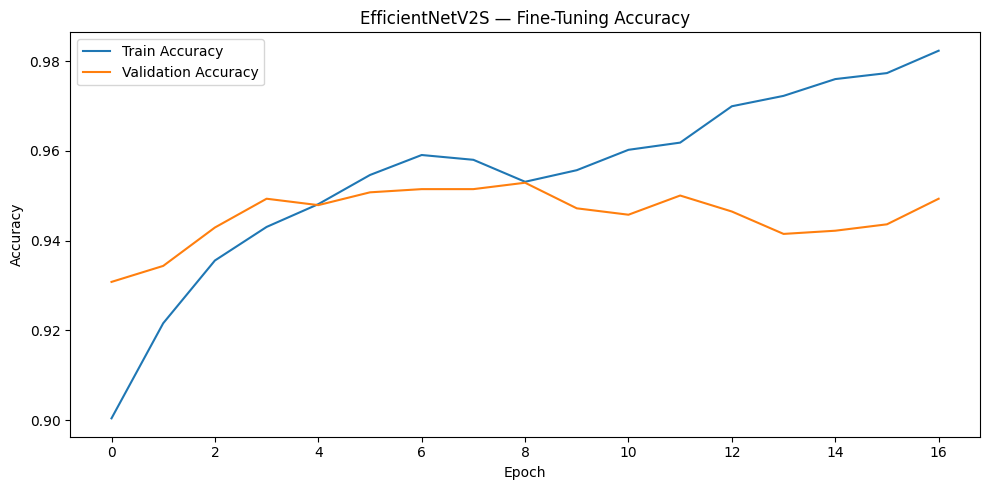

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(history_ft.history['accuracy'],     label='Train Accuracy')
plt.plot(history_ft.history['val_accuracy'], label='Validation Accuracy')
plt.title('EfficientNetV2S — Fine-Tuning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


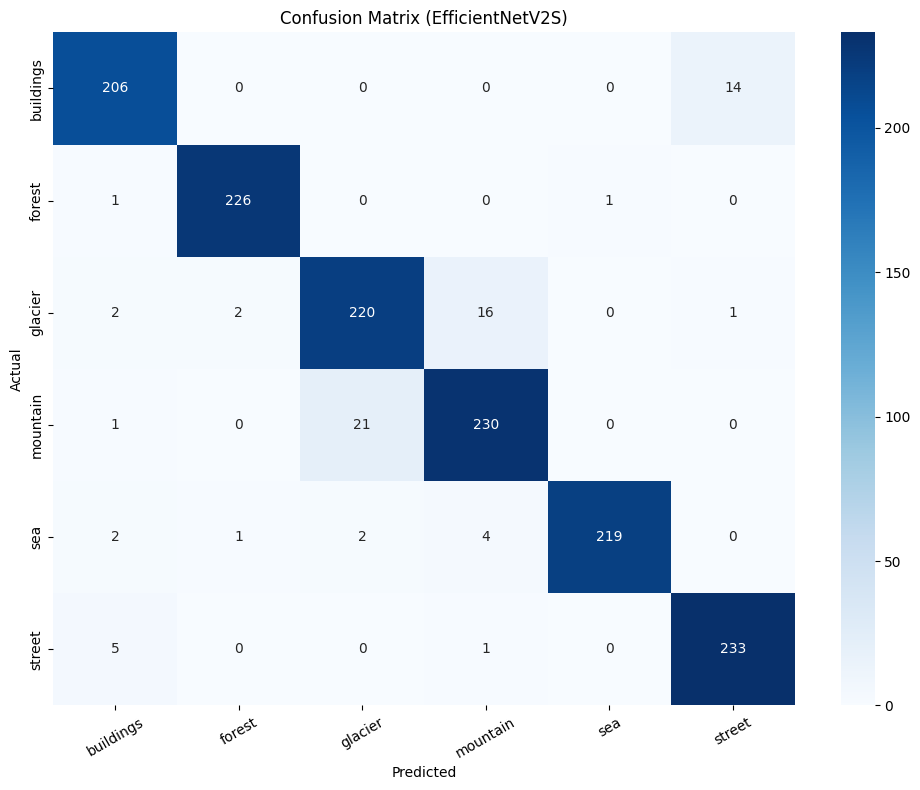

In [44]:
cm_eff = confusion_matrix(y_true_eff, y_pred_eff)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (EfficientNetV2S)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# **GUI**

In [46]:
# =========================================================
# INSTALLS (Uncomment if running on Colab/Kaggle)
# =========================================================
# !pip install -q gradio tensorflow pillow numpy

# =========================================================
# IMPORTS
# =========================================================
import os
import warnings

import gradio as gr
import numpy as np
from PIL import Image

import tensorflow as tf
from tensorflow import keras

warnings.filterwarnings("ignore")

# =========================================================
# GLOBALS
# =========================================================
EFF_IMG = 224
IMG_W = 150
IMG_H = 150

CLASSES = [
    "buildings",
    "forest",
    "glacier",
    "mountain",
    "sea",
    "street"
]

# =========================================================
# PREPROCESS HELPERS
# =========================================================
def preprocess_for_eff(img_pil):
    img = img_pil.resize((EFF_IMG, EFF_IMG))
    arr = np.array(img).astype(np.float32)
    arr = np.expand_dims(arr, 0)
    return arr

def preprocess_for_cnn(img_pil):
    img = img_pil.resize((IMG_W, IMG_H))
    arr = np.array(img).astype(np.float32) / 255.0
    arr = np.expand_dims(arr, 0)
    return arr

# =========================================================
# MOCK PREDICTION
# =========================================================
def generate_mock_prediction():
    probs = np.random.dirichlet(np.ones(len(CLASSES)), size=1)[0]
    top = int(np.argmax(probs))
    label = CLASSES[top]

    prob_dict = {
        cls: float(f"{p:.4f}")
        for cls, p in zip(CLASSES, probs)
    }

    return label, prob_dict

# =========================================================
# MODEL LOADER
# =========================================================
_loaded = {}

def get_model(name):

    if name in _loaded:
        return _loaded[name]

    try:

        if name == 'EfficientNetV2S':

            try:
                m = eff_model

            except NameError:

                model_path = '/content/eff_best.keras'

                if not os.path.exists(model_path):
                    raise FileNotFoundError(
                        f"Missing model file: {model_path}"
                    )

                m = keras.models.load_model(
                    model_path,
                    compile=False
                )

        else:

            try:
                m = cnn_model

            except NameError:

                model_path = '/content/best_cnn.keras'

                if not os.path.exists(model_path):
                    raise FileNotFoundError(
                        f"Missing model file: {model_path}"
                    )

                m = keras.models.load_model(
                    model_path,
                    compile=False
                )

    except Exception as e:
        print("Model load error:", e)
        return None

    _loaded[name] = m
    return m

# =========================================================
# PREDICTION FUNCTION
# =========================================================
def predict(img, model_choice):

    if img is None:
        return (
            "No image provided",
            {}
        )

    model = get_model(model_choice)

    # =====================================================
    # FALLBACK
    # =====================================================
    if model is None:

        label, probs = generate_mock_prediction()

        return (
            f"{label} (Mock Prediction)",
            probs
        )

    try:

        if model_choice == 'EfficientNetV2S':
            x = preprocess_for_eff(img)
        else:
            x = preprocess_for_cnn(img)

        preds = model.predict(x, verbose=0)

        probs = preds[0].tolist()

        top = int(np.argmax(probs))

        label = CLASSES[top]

        prob_dict = {
            cls: float(f'{p:.4f}')
            for cls, p in zip(CLASSES, probs)
        }

        return label, prob_dict

    except Exception as e:

        print("Prediction error:", e)

        label, probs = generate_mock_prediction()

        return (
            f"{label} (Fallback Prediction)",
            probs
        )

# =========================================================
# CUSTOM CSS
# =========================================================
custom_css = """
/* ===================================================== */
/* MAIN CONTAINER */
/* ===================================================== */

.gradio-container {
    max-width: 1450px !important;
    margin: auto;
    padding: 20px !important;
}

/* ===================================================== */
/* GLASS CARDS */
/* ===================================================== */

.glass-card {
    border-radius: 24px !important;
    border: 1px solid rgba(255,255,255,0.08);
    background: rgba(255,255,255,0.04);
    backdrop-filter: blur(10px);
    padding: 22px !important;
    box-shadow: 0 8px 30px rgba(0,0,0,0.08);
}

/* ===================================================== */
/* TITLE */
/* ===================================================== */

.project-title {
    font-size: 42px;
    font-weight: 800;
    margin-bottom: 10px;
    line-height: 1.1;
}

.project-desc {
    opacity: 0.75;
    font-size: 16px;
    margin-bottom: 22px;
}

/* ===================================================== */
/* TEAM MEMBERS */
/* ===================================================== */

.team-grid {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 8px 25px;
    margin-top: 15px;
}

.member {
    padding: 10px 14px;
    border-radius: 14px;
    background: rgba(255,255,255,0.05);
    font-size: 15px;
    font-weight: 500;
}

.supervisor {
    margin-top: 18px;
    padding: 12px;
    border-radius: 14px;
    text-align: center;
    font-weight: 600;
    background: linear-gradient(
        90deg,
        rgba(59,130,246,0.15),
        rgba(99,102,241,0.15)
    );
}

/* ===================================================== */
/* SECTION TITLES */
/* ===================================================== */

.section-title {
    font-size: 24px;
    font-weight: 700;
    margin-bottom: 18px;
}

/* ===================================================== */
/* BUTTON */
/* ===================================================== */

.gr-button-primary {
    border-radius: 16px !important;
    height: 55px !important;
    font-size: 17px !important;
    font-weight: 700 !important;
}

/* ===================================================== */
/* RESULT CARD */
/* ===================================================== */

.result-box {
    margin-top: 22px;
}

/* ===================================================== */
/* FOOTER */
/* ===================================================== */

.footer {
    text-align: center;
    opacity: 0.7;
    margin-top: 25px;
    font-size: 14px;
}

/* ===================================================== */
/* RESPONSIVE */
/* ===================================================== */

@media (max-width: 900px){

    .project-title{
        font-size: 30px;
        text-align: center;
    }

    .project-desc{
        text-align: center;
    }

    .team-grid{
        grid-template-columns: 1fr;
    }
}
"""

# =========================================================
# EXAMPLES
# =========================================================
example_images = [
    [
        "https://images.unsplash.com/photo-1511818966892-d7d671e672a2",
        "EfficientNetV2S"
    ],
    [
        "https://images.unsplash.com/photo-1441974231531-c6227db76b6e",
        "Simple CNN"
    ],
    [
        "https://images.unsplash.com/photo-1506744038136-46273834b3fb",
        "EfficientNetV2S"
    ]
]

# =========================================================
# THEME
# =========================================================
theme = gr.themes.Soft(
    primary_hue="blue",
    secondary_hue="slate",
    neutral_hue="gray",
    radius_size="lg",
    text_size="md"
)

# =========================================================
# UI
# =========================================================
with gr.Blocks(
    theme=theme,
    css=custom_css,
    title="Image Classification Project"
) as demo:

    # =====================================================
    # TOP SECTION
    # =====================================================
    with gr.Row(equal_height=True):

        # =================================================
        # LEFT SIDE -> PROJECT INFO
        # =================================================
        with gr.Column(scale=1):

            gr.HTML(
                """
                <div class="glass-card">

                    <div class="project-title">
                        🧠 Image Classification Project
                    </div>

                    <div class="project-desc">
                        Premium AI-powered scene classification system
                        built using TensorFlow & Gradio with responsive UI.
                    </div>

                    <div class="section-title">
                        👨‍💻 Team Members
                    </div>

                    <div class="team-grid">

                        <div class="member">
                            Mohammed Ahmed Mohammed Siddiq
                        </div>

                        <div class="member">
                            Ahmed Bahaa El-dien Mohammed Zaky
                        </div>

                        <div class="member">
                            Belal Rabea Khalifa
                        </div>

                        <div class="member">
                            Kareem Ashraf Hosny
                        </div>

                        <div class="member">
                            Ahmed Mohammed Mahmoud Abd-elkriem
                        </div>

                    </div>

                    <div class="supervisor">
                        Under Supervision of Dr. Said
                    </div>

                </div>
                """
            )

        # =================================================
        # RIGHT SIDE -> IMAGE INPUT
        # =================================================
        with gr.Column(scale=1):

            with gr.Group(elem_classes="glass-card"):

                gr.HTML(
                    """
                    <div class="section-title">
                        📤 Upload Image
                    </div>
                    """
                )

                img_in = gr.Image(
                    type="pil",
                    label="Input Image",
                    height=360
                )

                model_choice = gr.Radio(
                    ['EfficientNetV2S', 'Simple CNN'],
                    value='EfficientNetV2S',
                    label='Select Model'
                )

                predict_btn = gr.Button(
                    "🚀 Run Classification",
                    variant="primary",
                    size="lg"
                )

    # =====================================================
    # RESULTS BELOW
    # =====================================================
    with gr.Group(elem_classes="glass-card result-box"):

        gr.HTML(
            """
            <div class="section-title">
                📊 Prediction Results
            </div>
            """
        )

        with gr.Row():

            out_label = gr.Textbox(
                label='Predicted Label',
                interactive=False,
                scale=1
            )

            out_probs = gr.Label(
                num_top_classes=6,
                label='Classification Probabilities',
                scale=2
            )

    # =====================================================
    # EXAMPLES
    # =====================================================
    gr.Markdown("## 🖼️ Quick Examples")

    gr.Examples(
        examples=example_images,
        inputs=[img_in, model_choice],
        outputs=[out_label, out_probs],
        fn=predict,
        cache_examples=False
    )

    # =====================================================
    # FOOTER
    # =====================================================
    gr.HTML(
        """
        <div class="footer">
            Designed with responsive premium UI •
            Supports Light & Dark Mode automatically
        </div>
        """
    )

    # =====================================================
    # EVENTS
    # =====================================================
    predict_btn.click(
        fn=predict,
        inputs=[img_in, model_choice],
        outputs=[out_label, out_probs]
    )

# =========================================================
# LAUNCH
# =========================================================
if __name__ == "__main__":

    try:

        demo.launch(
            share=True,
            debug=False
        )

    except Exception:

        demo.launch()

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://60f006b58a52052461.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
